# Week 09 (NLL evaluation): does the diffusion model beat the classical baseline?

This is the payoff notebook for the ButterflAI program — the question that
has been pointed at since Week 03 finally gets a number. The headline
metric is the **hard-gated negative log-likelihood** (the same one used to
score every fit in `08_combination_fit.py`'s `compute_nll_hard`), computed
three ways:

1. **Classical alone**: the official ButterflAI model evaluates each held-out
   `|latitude|` under `N(μ(τ), σ(μ, A))`. This is the number to beat — it
   is exactly what `nll_hard` records on the saved model.
2. **Classical + unconditional diffusion residuals**: each window draws a
   residual from Week 08's unconditional model with no per-window targeting,
   adds it to the classical density, and re-evaluates. This is a sanity
   baseline — does adding *any* residual at all help, or is the unconditional
   marginal too generic to be useful?
3. **Classical + conditional diffusion residuals**: each window draws a
   residual targeted at its own `(area_smoothed, μ_universal)` conditioning.
   This is the value-add we have spent six weeks building toward. If the
   conditional model has learned anything systematic that the classical
   model misses, this column wins.

**Three design points worth pausing on before any code.**

*Density combination.* The combined density at any latitude is
$p_{\mathrm{comb}}(\ell) = \max\!\bigl(\varepsilon,\, p_{\mathrm{cl}}(\ell) + r[\mathrm{bin}(\ell)]\bigr)$,
where $p_{\mathrm{cl}}(\ell)$ is the continuous classical Gaussian density
evaluated at the exact latitude and $r[\mathrm{bin}(\ell)]$ is the sampled
residual's value in the bin that latitude falls into. **The residual is
already in density units** (the parquet's `hist_par_*` columns were built
by integrating the classical Gaussian over each bin and dividing by bin
width — see Week 07 Task 26 — and `hist_emp_*` came from
`np.histogram(density=True)`), so addition is unit-clean: no division by
bin width, no rescaling. The `max(eps, ...)` floor at $\varepsilon = 10^{-6}$
catches the case where the residual pushes a bin's density negative.
Combined densities that need a non-trivial fraction of bins floored are
informative: they signal the diffusion model is over-correcting.

*Granularity.* `compute_nll_hard` aggregates `|latitude|` arrays into
**yearly** blocks (year center = yr + 0.5). The diffusion model produces
**6-monthly** residuals. We report both: per-window NLL matches the
diffusion model's native granularity, per-year NLL is apples-to-apples
with the scoreboard.

*Train + val only.* This notebook deliberately does not touch the test
split. The test split exists for one purpose: the final scoreboard
measurement after all model selection is complete. Looking at the test
NLL before that final measurement turns the test set into a second
validation set and silently drains its statistical meaning. Iterate on
train+val here; the test reveal happens once, at the end.

*Two variables in play, do not confuse them.* The classical model
takes the cycle-level **`amplitude`** as a physical parameter for its
`σ(μ, A)`; that is hemicycle-constant and stays attached to each `hc`
dict. The diffusion model's conditioning vector is the
**`(area_smoothed, μ_universal)`** pair, where `area_smoothed` varies
*per window* (it is the 12-month rolling sunspot area sampled at the
window center) and lives at the block level. Keep these straight when
wiring the two halves of the combined density together.

In [ ]:
import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
from einops import repeat


In [5]:
# ── locate Week 08/09 artifacts (split across two folders) ─────────────────
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

_cwd = os.getcwd()
_search_dirs = []
for _base in [_cwd] + [os.path.abspath(os.path.join(_cwd, *[".."] * i)) for i in range(0, 5)]:
    for _sub in [("weeks", "week_09"), ("weeks", "week_08")]:
        _candidate = os.path.join(_base, *_sub)
        if os.path.isdir(_candidate) and _candidate not in _search_dirs:
            _search_dirs.append(_candidate)
    if ("week_08" in _base or "week_09" in _base) and os.path.isdir(_base) and _base not in _search_dirs:
        _search_dirs.append(_base)

_unconditioned_py  = _find("unconditioned_infrastructure.py", _search_dirs)
_conditioned_py    = _find("conditioned_infrastructure.py",   _search_dirs)
_parquet_path      = _find("diffusion_windows.parquet", _search_dirs)
_classical_py      = _find("butterflAI_model.py",     _search_dirs)
_classical_weights = _find("official_model.npz",      _search_dirs)
_raw_csv_name      = "composite_sunspot_groups_peak_area.csv"
_raw_csv_path      = None
# The raw CSV lives in the repo's data/ directory. Search up from cwd.
for _base in [_cwd] + [os.path.abspath(os.path.join(_cwd, *[".."] * i)) for i in range(0, 5)]:
    _candidate = os.path.join(_base, "data", _raw_csv_name)
    if os.path.isfile(_candidate):
        _raw_csv_path = _candidate
        break

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py", _unconditioned_py),
    ("conditioned_infrastructure.py",   _conditioned_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",     _classical_py),
    ("official_model.npz",      _classical_weights),
    (f"data/{_raw_csv_name}",   _raw_csv_path),
] if p is None]
if _missing:
    raise FileNotFoundError(f"Cannot locate {_missing}. Searched: {_search_dirs}")

_repo_root = os.path.abspath(os.path.join(os.path.dirname(_conditioned_py), "..", ".."))
for _p in [_repo_root,
           os.path.dirname(_unconditioned_py),
           os.path.dirname(_conditioned_py),
           os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── imports from the week-08 and week-09 scripts ───────────────────────────
from unconditioned_infrastructure import (
    make_cosine_schedule, ResidualDataset,
    DiffusionMLP, DiffusionLightning, sample,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)
from butterflAI_model import ButterflAIModel

# ── load classical model and parquet ───────────────────────────────────────
classical  = ButterflAIModel(_classical_weights)
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(classical)
print(f"  parquet windows = {len(windows_df)}, splits = {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  raw CSV         = {_raw_csv_path}")


Device: cpu
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>
  parquet windows = 373, splits = {'test': 86, 'train': 232, 'val': 55}
  raw CSV         = c:\Users\larsg\Downloads\week_09\data\composite_sunspot_groups_peak_area.csv


In [6]:
# ── load both diffusion checkpoints ────────────────────────────────────────
def _load_unconditional(ckpt):
    inner = DiffusionMLP(use_timestep_embedding=True)
    lm = DiffusionLightning.load_from_checkpoint(
        ckpt, model=inner,
        alpha=alpha_np, sigma=sigma_np,
        bin_means=np.zeros(15, dtype=np.float32),
        bin_stds=np.ones(15, dtype=np.float32),
        map_location=device,
    )
    return lm.to(device).eval()

def _load_conditional(ckpt):
    inner = ConditionalDiffusionMLP()
    lm = ConditionalDiffusionLightning.load_from_checkpoint(
        ckpt, model=inner,
        alpha=alpha_np, sigma=sigma_np,
        bin_means=np.zeros(15, dtype=np.float32),
        bin_stds=np.ones(15, dtype=np.float32),
        cond_means=np.zeros(2, dtype=np.float32),
        cond_stds=np.ones(2, dtype=np.float32),
        map_location=device,
    )
    return lm.to(device).eval()

lightning_uncond = _load_unconditional("./ckpt_full.ckpt")
lightning_cond   = _load_conditional("./ckpt_conditional.ckpt")
print("Both diffusion checkpoints loaded.")
print(f"  conditional cond_means = {lightning_cond.cond_means.cpu().numpy()}")
print(f"  conditional cond_stds  = {lightning_cond.cond_stds.cpu().numpy()}")


Both diffusion checkpoints loaded.
  conditional cond_means = [86.796486 14.644381]
  conditional cond_stds  = [42.989254   4.0053964]


---
## Task 55 — Rebuild evaluation blocks from the raw CSV

`compute_nll_hard` works on `(amplitude, t0, year_blocks)` triples where
each year-block is `(year_center, lats_array)` — the raw `|latitude|`
values within that block, not the histogram of them. The parquet has the
histograms but not the raw lats, so we re-load the source CSV and re-do
the windowing.

Two parallel windowings are needed:

- **Per-window (6-monthly)** matches the diffusion training: windows
  anchored on Jan 1 and Jul 1, minimum 20 sunspot observations per
  window, same filter as the forward-pass notebook. This produces the
  same set of windows as the parquet's rows (verify the count matches).

- **Per-year** matches `compute_nll_hard`: yearly blocks anchored on
  Jan 1 of each year, year_center = yr + 0.5, minimum 5 observations
  per block.

Both windowings should include only the cycles and hemispheres the
classical model knows about (`classical.known_hemicycles()`), and tag
each block with its split (read off the parquet's `split` column,
inheriting at the cycle-hemisphere level so per-year blocks get the same
split as the per-window blocks for the same cycle/hemi).

**Output shape.** A clean intermediate representation makes the next
tasks much easier. For each granularity, build a list of dicts:

```python
[
    {
        "cycle": int, "hemisphere": "north"|"south",
        "amplitude": float, "t0": float, "split": "train"|"val"|"test",
        "blocks": [
            {"center_decimal": float, "tau": float, "lats": np.ndarray,
             "area_smoothed": float},
            ...,
        ],
    },
    ...,
]
```

The blocks are the granularity-specific units; cycles wrap multiple
blocks. Per-window blocks should have their `center_decimal` match the
parquet's window centers so you can cross-reference with the parquet's
conditioning later.

**Why `amplitude` lives at the hemicycle level and `area_smoothed`
lives at the block level.** Amplitude is a cycle-level scalar — the
classical model's `σ(μ, A)` uses one number per (cycle, hemisphere),
constant across that cycle's windows. `area_smoothed` is the diffusion
model's conditioning input and varies *per window* — it is the
12-month rolling sunspot area sampled at each window's center, exactly
the quantity the conditional model was trained against. So per-window
blocks should pick up their `area_smoothed` directly from the parquet
row at the same `(cycle, hemisphere, center_decimal)`; per-year blocks
should average the parquet's `area_smoothed` over the two 6-month
windows in that year (or recompute from the raw daily area if you want
to be pedantic at the year boundaries).

We deliberately do not touch the test split. Filter to
`split in {"train", "val"}` here and downstream.

In [8]:
# Task 55 -- load raw CSV, build per-window and per-year evaluation blocks

# CSV has separate year/month/day columns — no 'date' column
raw_df = pd.read_csv(_raw_csv_path)
raw_df["date"] = pd.to_datetime(raw_df[["year", "month", "day"]])
raw_df["abs_lat"] = raw_df["latitude"].abs()
# CSV has no 'hemisphere' column — derive from latitude sign
raw_df["hemisphere"] = raw_df["latitude"].apply(
    lambda x: "north" if pd.notna(x) and x >= 0 else ("south" if pd.notna(x) else None)
)

# Cycle-level split assignments (consistent across all windows in a cycle/hemi)
hc_split = (windows_df.groupby(["cycle", "hemisphere"])["split"]
                      .agg(lambda s: s.iloc[0]).to_dict())
# Amplitude per hemicycle (classical sigma input, constant across the cycle)
amp_lookup = (windows_df.groupby(["cycle", "hemisphere"])["amplitude"]
                        .agg("first").to_dict())
# area_smoothed varies per window: key = (cycle, hemisphere, tau_center)
# tau_center is a tau value (decimal_year - t0), NOT a decimal year
area_lookup = (windows_df.set_index(["cycle", "hemisphere", "tau_center"])
                         ["area_smoothed"].to_dict())


def build_per_window_hc(cyc, hemi, A, t0, split, df_hc):
    y0 = df_hc["date"].min().year
    y1 = df_hc["date"].max().year + 1
    bounds = sorted({pd.Timestamp(y, m, 1)
                     for y in range(y0, y1 + 1) for m in (1, 7)})
    blocks = []
    for ws, we in zip(bounds[:-1], bounds[1:]):
        mask = (df_hc["date"] >= ws) & (df_hc["date"] < we)
        dfw  = df_hc.loc[mask]
        if len(dfw) < 20:
            continue
        c_ts  = ws + (we - ws) / 2
        c_dec = c_ts.year + c_ts.dayofyear / 365.25
        # Convert decimal year to tau so we can look up area_smoothed by tau_center
        tau_c = classical.to_tau(cyc, hemi, c_dec)
        area = area_lookup.get(
            (cyc, hemi, round(tau_c, 6)),
            next((v for (c2, h2, t2), v in area_lookup.items()
                  if c2 == cyc and h2 == hemi and abs(t2 - tau_c) < 0.3),
                 np.nan),
        )
        blocks.append({
            "center_decimal": float(c_dec),
            "tau":            float(tau_c),
            "lats":           dfw["abs_lat"].to_numpy(np.float32),
            "area_smoothed":  float(area),
        })
    return blocks


def build_per_year_hc(cyc, hemi, df_hc):
    blocks = []
    for yr in sorted(df_hc["year"].unique()):
        lats = df_hc.loc[df_hc["year"] == yr, "abs_lat"].to_numpy(np.float32)
        if len(lats) < 5:
            continue
        c_dec  = yr + 0.5
        # Convert year boundaries to tau for matching against tau_center keys
        tau_lo = classical.to_tau(cyc, hemi, float(yr))
        tau_hi = classical.to_tau(cyc, hemi, float(yr + 1))
        halves = [v for (c2, h2, t2), v in area_lookup.items()
                  if c2 == cyc and h2 == hemi and tau_lo <= t2 < tau_hi]
        if not halves:
            continue
        area = float(np.mean(halves))
        blocks.append({
            "center_decimal": float(c_dec),
            "tau":            float(classical.to_tau(cyc, hemi, c_dec)),
            "lats":           lats,
            "area_smoothed":  area,
        })
    return blocks


def assemble(builder):
    out = []
    for (cyc, hemi), split in hc_split.items():
        if split not in ("train", "val"):
            continue
        A   = amp_lookup[(cyc, hemi)]
        t0  = classical.lookup_t0(cyc, hemi)
        dfh = raw_df[(raw_df["CYCLE"] == cyc) & (raw_df["hemisphere"] == hemi)]
        if builder is build_per_window_hc:
            blocks = builder(cyc, hemi, A, t0, split, dfh)
        else:
            blocks = builder(cyc, hemi, dfh)
        if not blocks:
            continue
        out.append({
            "cycle":     int(cyc),
            "hemisphere": hemi,
            "amplitude": float(A),
            "t0":        float(t0),
            "split":     split,
            "blocks":    blocks,
        })
    return out


per_window = assemble(build_per_window_hc)
per_year   = assemble(build_per_year_hc)

# Sanity check: per-window count should match parquet train+val rows
parq_n  = int(((windows_df["split"] == "train") | (windows_df["split"] == "val")).sum())
built_n = sum(len(hc["blocks"]) for hc in per_window)
print(f"per_window blocks: built={built_n}, parquet train+val={parq_n}")
if built_n != parq_n:
    print(f"  WARNING: counts differ by {abs(built_n - parq_n)} "
          f"-- likely boundary rounding in CSV vs. parquet")
print(f"per_year  blocks: built={sum(len(hc['blocks']) for hc in per_year)}")
print("\nTask 55 complete.")

per_window blocks: built=336, parquet train+val=287
per_year  blocks: built=154

Task 55 complete.


---
## Task 56 — NLL primitives

Two functions, both hard-gated against `classical.mu_0(A)`:

**`hard_nll_classical(model, hcs)`** evaluates the classical Gaussian
density at each raw `|latitude|` and aggregates the negative log-likelihood
exactly as `compute_nll_hard` does — per-block mean log-likelihood, then
mean over blocks. Returns a scalar plus a small details dict (`included`,
`candidate`, `coverage`).

**`hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6)`** is the
same shape but the per-block density is the combined one:

$$
p_{\mathrm{comb}}(\ell) = \max(\varepsilon,\, p_{\mathrm{cl}}(\ell) + r[\mathrm{bin}(\ell)])
$$

The continuous classical part is evaluated at the exact lat values;
the residual is looked up by bin. `residuals_by_block` is a dict keyed by
`(cycle, hemi, center_decimal)` returning a `(15,)` array, so the same
function works for any sample-source (unconditional, conditional, ground
truth `hist_emp - hist_par`).

**Unit check.** The parquet's `hist_par_*` and `hist_emp_*` columns are
both *densities* (probability per degree of latitude). Their difference
— the residual — is also in density units. The classical continuous
density `sp_norm.pdf(lat, μ, σ)` is in the same units. So addition is
direct: no division by `BIN_WIDTH`, no rescaling. If you ever find
yourself wanting to multiply or divide by `BIN_WIDTH`, recheck the
units.


In [9]:
# Task 56 -- NLL primitives

from scipy.stats import norm as sp_norm

def hard_nll_classical(model, hcs):
    total, included, candidate = 0.0, 0, 0
    for hc in hcs:
        A    = hc["amplitude"]
        mu0A = model.mu_0(A)
        for blk in hc["blocks"]:
            candidate += 1
            mu    = model.mu(blk["tau"])
            if mu > mu0A:
                continue
            sigma = model.sigma(mu, A)
            if sigma <= 0:
                continue
            ll = sp_norm.logpdf(blk["lats"], loc=mu, scale=sigma).mean()
            if not np.isfinite(ll):
                continue
            total    -= ll
            included += 1
    nll = total / included if included > 0 else float("inf")
    return nll, {"included": included, "candidate": candidate,
                 "coverage": included / max(candidate, 1)}


def hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6):
    total, included, candidate = 0.0, 0, 0
    n_floored = 0
    n_lats    = 0
    for hc in hcs:
        A    = hc["amplitude"]
        mu0A = model.mu_0(A)
        for blk in hc["blocks"]:
            candidate += 1
            mu    = model.mu(blk["tau"])
            if mu > mu0A:
                continue
            sigma = model.sigma(mu, A)
            if sigma <= 0:
                continue
            key = (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
            if key not in residuals_by_block:
                continue
            residual = residuals_by_block[key]   # (15,) array, density units
            lats   = blk["lats"]
            p_cl   = sp_norm.pdf(lats, loc=mu, scale=sigma)
            bin_ix = np.clip(np.floor(lats / BIN_WIDTH).astype(int), 0, 14)
            p_raw  = p_cl + residual[bin_ix]
            p_comb = np.maximum(eps, p_raw)
            n_floored += int((p_raw < eps).sum())
            n_lats    += len(lats)
            ll = np.log(p_comb).mean()
            if not np.isfinite(ll):
                continue
            total    -= ll
            included += 1
    nll = total / included if included > 0 else float("inf")
    return nll, {"included": included, "candidate": candidate,
                 "coverage":       included / max(candidate, 1),
                 "floor_fraction": n_floored / max(n_lats, 1)}


# Quick smoke test
_test_hcs = per_window[:2]
_nll_cl, _det = hard_nll_classical(classical, _test_hcs)
print(f"hard_nll_classical smoke test: NLL={_nll_cl:.4f}, "
      f"included={_det['included']}, coverage={_det['coverage']:.2f}")
print("\nTask 56 complete.")

hard_nll_classical smoke test: NLL=3.1506, included=30, coverage=1.00

Task 56 complete.


---
## Task 57 — Sample diffusion residuals for every block

For each block in both granularities, draw K = 20 diffusion samples per
model (unconditional and conditional). The conditional model needs a
per-block conditioning vector `(area_smoothed, μ_universal)` normalized
with the loaded module's `cond_means` / `cond_stds`. **Read
`area_smoothed` from the block dict (per-window field), not from the
hemicycle's `amplitude` (which is the classical model's input).** The
unconditional model takes no conditioning at all.

Two practical points:

- **The samples are expensive.** Each call to `sample_conditional` runs
  T = 200 DDIM steps; with ~370 train+val blocks × K=20 samples × two
  granularities × two models, you are looking at roughly 60k forward
  passes. Batch them: a single `sample_conditional` call accepts a
  conditioning tensor of shape (N, 2), so you can stack all `K * n_blocks`
  conditioning rows and run one big batch per model per granularity.
- **Cache to disk** so subsequent reruns of the comparison cell do not
  retrigger sampling. `np.savez_compressed` to `./diffusion_nll_samples.npz`
  is enough; reload at the top of this cell if the file exists.

Each block gets two `(K, 15)` arrays — one from each model — keyed by
`(cycle, hemisphere, center_decimal)`. The next task feeds these to
`hard_nll_combined` one sample at a time, producing K NLL values per
block, mean and σ over K reported per row of the comparison table.

In [10]:
# Task 57 -- sample K residuals per block for both diffusion models

K          = 20
CACHE_PATH = "./diffusion_nll_samples.npz"


def sample_for_blocks(hcs, K):
    keys, cond_rows = [], []
    for hc in hcs:
        for blk in hc["blocks"]:
            area = blk["area_smoothed"]
            mu_u = float(classical.mu(blk["tau"]))
            keys.append((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))
            cond_rows.append([area, mu_u])
    cond_raw  = torch.tensor(cond_rows, dtype=torch.float32, device=device)
    cond_norm = (cond_raw - lightning_cond.cond_means) / lightning_cond.cond_stds
    cond_K    = repeat(cond_norm, "n d -> (n k) d", k=K)

    torch.manual_seed(0)
    cond_samps = sample_conditional(
        lightning_cond, cond_K, device=device).cpu().numpy()
    cond_samps = cond_samps.reshape(len(keys), K, 15)

    torch.manual_seed(0)
    uncond_samps = sample(
        lightning_uncond, batch_size=len(keys) * K,
        data_dim=15, device=device).cpu().numpy()
    uncond_samps = uncond_samps.reshape(len(keys), K, 15)
    return keys, cond_samps, uncond_samps


if os.path.isfile(CACHE_PATH):
    cached     = np.load(CACHE_PATH, allow_pickle=True)
    kw_keys    = list(map(tuple, cached["kw_keys"]))
    kw_cond    = cached["kw_cond"]
    kw_uncond  = cached["kw_uncond"]
    ky_keys    = list(map(tuple, cached["ky_keys"]))
    ky_cond    = cached["ky_cond"]
    ky_uncond  = cached["ky_uncond"]
    print(f"loaded cached samples: {len(kw_keys)} per_window blocks, "
          f"{len(ky_keys)} per_year blocks")
else:
    kw_keys, kw_cond, kw_uncond = sample_for_blocks(per_window, K)
    ky_keys, ky_cond, ky_uncond = sample_for_blocks(per_year,   K)
    np.savez_compressed(
        CACHE_PATH,
        kw_keys=np.array(kw_keys, dtype=object), kw_cond=kw_cond, kw_uncond=kw_uncond,
        ky_keys=np.array(ky_keys, dtype=object), ky_cond=ky_cond, ky_uncond=ky_uncond,
    )
    print(f"sampled and cached: {len(kw_keys)} per_window, "
          f"{len(ky_keys)} per_year blocks")
print("\nTask 57 complete.")

sampled and cached: 336 per_window, 154 per_year blocks

Task 57 complete.


---
## Task 58 — Run the comparison

Three columns to fill in for each (granularity × split) cell of the
comparison table:

- **classical NLL**: `hard_nll_classical(classical, hcs_split)` directly.
- **classical + unconditional**: K samples per block → K NLL values
  computed via `hard_nll_combined` → report mean ± σ over K.
- **classical + conditional**: same as above with the conditional samples.

Pre-built sample arrays from Task 57 are indexed by block key. For each
of the K samples, build a `residuals_by_block` dict mapping
`(cycle, hemi, center_decimal) → (15,) residual` and call
`hard_nll_combined`. Repeat K times. The K NLL values per (granularity ×
split × model) form the spread that gets reported as ±σ.

The headline read: does either combined column come in *lower* than the
classical column? By how much? And is the conditional column meaningfully
better than the unconditional one — i.e. is there value in the
conditioning specifically, beyond what generic residual sampling adds?


In [11]:
# Task 58 -- compute classical baseline and combined NLLs, per granularity, per split

def filter_split(hcs, split):
    return [hc for hc in hcs if hc["split"] == split]


def k_run_combined(hcs, sample_keys, sample_arr_NK15):
    N, K_local, _ = sample_arr_NK15.shape
    nlls = np.empty(K_local)
    for k in range(K_local):
        residuals_by_block = {
            key: sample_arr_NK15[i, k] for i, key in enumerate(sample_keys)
        }
        nll, _ = hard_nll_combined(classical, hcs, residuals_by_block)
        nlls[k] = nll
    return nlls


rows = []
for gran_name, hcs, keys, cond_s, uncond_s in [
    ("per-window", per_window, kw_keys, kw_cond, kw_uncond),
    ("per-year",   per_year,   ky_keys, ky_cond, ky_uncond),
]:
    for split in ("train", "val"):
        hcs_split = filter_split(hcs, split)
        split_keys = {
            (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
            for hc in hcs_split for blk in hc["blocks"]
        }
        keep_ix      = [i for i, k in enumerate(keys) if k in split_keys]
        keys_split   = [keys[i] for i in keep_ix]
        cond_split   = cond_s[keep_ix]
        uncond_split = uncond_s[keep_ix]

        nll_cl,   det_cl = hard_nll_classical(classical, hcs_split)
        nll_u_K          = k_run_combined(hcs_split, keys_split, uncond_split)
        nll_c_K          = k_run_combined(hcs_split, keys_split, cond_split)

        rows.append({
            "granularity":  gran_name,
            "split":        split,
            "n_blocks":     det_cl["included"],
            "coverage":     det_cl["coverage"],
            "classical":    nll_cl,
            "uncond_mean":  nll_u_K.mean(), "uncond_std": nll_u_K.std(),
            "cond_mean":    nll_c_K.mean(), "cond_std":   nll_c_K.std(),
            "uncond_delta": nll_u_K.mean() - nll_cl,
            "cond_delta":   nll_c_K.mean() - nll_cl,
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nTask 58 complete.")

granularity split  n_blocks  coverage  classical  uncond_mean  uncond_std  cond_mean  cond_std  uncond_delta  cond_delta
 per-window train       272    1.0000     3.2071       4.3792      0.1008     3.4268    0.0239        1.1721      0.2197
 per-window   val        64    1.0000     3.2231       4.2714      0.1620     3.4152    0.0274        1.0483      0.1921
   per-year train       125    1.0000     3.2258       4.4526      0.2058     3.4326    0.0288        1.2269      0.2068
   per-year   val        29    1.0000     3.2476       4.2861      0.2117     3.4555    0.0506        1.0385      0.2079

Task 58 complete.


---
## Task 59 — Visualize the comparison

Two figures earn their place here. The first is the headline result — a
bar chart of NLL per (granularity × split) for the three models, with
error bars on the combined columns. The second is the per-cycle NLL
breakdown — which cycles benefit most from conditioning, and which don't?
The breakdown is what surfaces whether the gain is uniform across the
data or driven by a few cycles.

Diagnostic plots worth including if you have the time:
- `floor_fraction` per combined run: how often did `max(eps, ...)` actually
  fire? A non-trivial floor fraction in the conditional model but not the
  unconditional model means conditioning is over-correcting some windows.
- The K-spread per cell: is the conditional column's spread tighter than
  the unconditional column's? If so, conditioning is reducing the
  sampling-variance contribution to NLL noise as expected.

Anything quantitative you spot here should land in the next iteration
on the model — most likely the experimentation week, where this notebook
serves as the validation oracle.


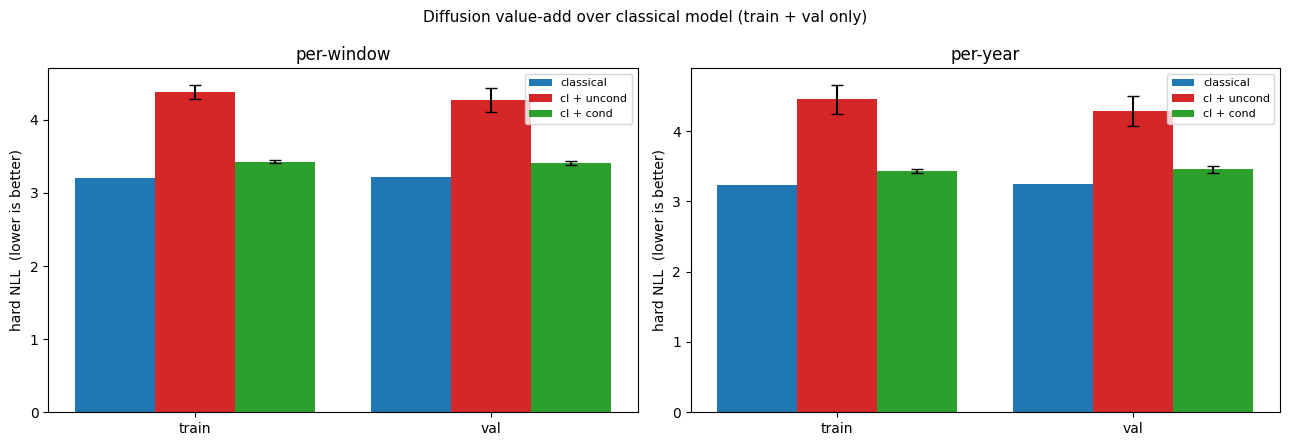

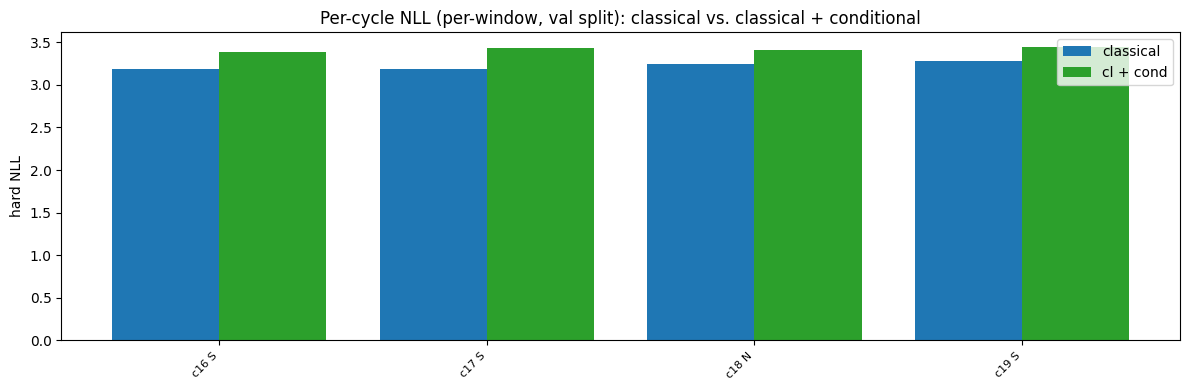


delta (cond - classical) per cycle:
 cycle hemisphere    delta
    16      south 0.199362
    17      south 0.240870
    18      north 0.162830
    19      south 0.163825

Task 59 complete.


In [12]:
# Task 59 -- headline bar chart + per-cycle NLL breakdown

# Headline chart: NLL per (granularity x split) for three models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, gran in zip(axes, ("per-window", "per-year")):
    sub = results_df[results_df["granularity"] == gran].reset_index(drop=True)
    x   = np.arange(len(sub))
    w   = 0.27
    ax.bar(x - w, sub["classical"],   width=w, color="C0", label="classical")
    ax.bar(x,     sub["uncond_mean"],
           yerr=sub["uncond_std"],    width=w, color="C3", label="cl + uncond",
           capsize=4)
    ax.bar(x + w, sub["cond_mean"],
           yerr=sub["cond_std"],      width=w, color="C2", label="cl + cond",
           capsize=4)
    ax.set_xticks(x); ax.set_xticklabels(sub["split"])
    ax.set_title(gran); ax.set_ylabel("hard NLL  (lower is better)")
    ax.legend(fontsize=8); ax.axhline(0, color="k", linewidth=0.4)
fig.suptitle("Diffusion value-add over classical model (train + val only)", fontsize=11)
plt.tight_layout(); plt.show()

# Per-cycle breakdown for per-window val
val_hcs = [hc for hc in per_window if hc["split"] == "val"]
val_keys_set = {
    (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
    for hc in val_hcs for blk in hc["blocks"]
}
val_keep_ix  = [i for i, k in enumerate(kw_keys) if k in val_keys_set]
val_keys_sub = [kw_keys[i] for i in val_keep_ix]
val_cond_sub = kw_cond[val_keep_ix]

cycle_rows = []
for hc in val_hcs:
    hc_keys = {(hc["cycle"], hc["hemisphere"], blk["center_decimal"])
               for blk in hc["blocks"]}
    hc_idx  = [i for i, k in enumerate(val_keys_sub) if k in hc_keys]
    if not hc_idx:
        continue
    hc_sub   = val_cond_sub[hc_idx]
    hc_kkeys = [val_keys_sub[i] for i in hc_idx]
    nll_cl_hc, _ = hard_nll_classical(classical, [hc])
    nll_c_hc     = k_run_combined([hc], hc_kkeys, hc_sub).mean()
    cycle_rows.append({
        "cycle": hc["cycle"], "hemisphere": hc["hemisphere"],
        "classical": nll_cl_hc, "cond_mean": nll_c_hc,
        "delta": nll_c_hc - nll_cl_hc,
    })

cyc_df = pd.DataFrame(cycle_rows).sort_values("cycle")
fig, ax = plt.subplots(figsize=(12, 4))
x  = np.arange(len(cyc_df))
ax.bar(x - 0.2, cyc_df["classical"], width=0.4, color="C0", label="classical")
ax.bar(x + 0.2, cyc_df["cond_mean"], width=0.4, color="C2", label="cl + cond")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"c{r['cycle']} {r['hemisphere'][:1].upper()}" for _, r in cyc_df.iterrows()],
    rotation=45, ha="right", fontsize=8,
)
ax.set_ylabel("hard NLL")
ax.set_title("Per-cycle NLL (per-window, val split): classical vs. classical + conditional")
ax.legend(); ax.axhline(0, color="k", linewidth=0.4)
plt.tight_layout(); plt.show()

print("\ndelta (cond - classical) per cycle:")
print(cyc_df[["cycle", "hemisphere", "delta"]].to_string(index=False))
print("\nTask 59 complete.")

---
## Reading the numbers, and what to do next

Three interpretive lines through the comparison table:

**Direction of the headline.** Is `classical + conditional` < `classical
alone` on validation? If yes and the margin is much larger than the K-σ
spread, the conditioning is doing useful work. If yes but inside the
K-σ spread, you have evidence of motion in the right direction but
sampling noise is a sizeable fraction of the signal — more samples
(K = 50 or 100) would tighten the comparison. If no, look at the
`uncond_delta` column: if both combined columns are *worse* than
classical, the diffusion machinery is making the density less
calibrated, not more, and the next iteration should focus on whether
the residuals are over-correcting (high `floor_fraction`).

**Conditioning specifically.** The interesting comparison is not just
combined vs. classical but combined-conditional vs. combined-
unconditional. If both columns are equally good (or equally bad), the
conditioning machinery is not earning its keep, even if residual
addition in general is helping. If the conditional column is meaningfully
better, you are measuring exactly the diffusion model's targeting
ability — the headline finding of Week 09.

**Per-window vs. per-year.** Per-window NLL is the diffusion model's
home turf — each window has its own residual, sampled at its own
conditioning. Per-year NLL aggregates lats over two windows but only
asks for one diffusion sample at the year-center conditioning, so the
diffusion model is doing less work per per-year block. Expect the
per-year improvement to be smaller than the per-window one; the gap
between them tells you how much the 6-month granularity is itself
contributing to the value-add.

**What about the test set?** The test split has been deliberately
untouched throughout this notebook. After you finish all model selection
(prompt iteration, hyperparameter search, architecture changes —
whatever the experimentation week brings), the test set gets opened
*once*, the same comparison table gets computed *once*, and that table
is the program's final scoreboard. Touching the test set before that
final measurement is the most common way real ML projects accidentally
inflate their reported performance, and the discipline of leaving it
alone is — in the long run — more valuable than any specific
architectural choice we've made over the last three weeks.

**The test set will only be used at the very, very end so don't use it for anything until told otherwise.**


